<a href="https://colab.research.google.com/github/BrenoAmancio/IA-BSI/blob/main/C%C3%B3pia_de_FASHIONMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importando os dados do Dataset Fashion MNIST

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# Normalização

In [ ]:
from torchvision import transforms

# Etapa 1: Carregar temporariamente o dataset SEM normalização
temp_transform = transforms.Compose([transforms.ToTensor()])
temp_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=temp_transform)
temp_loader = DataLoader(temp_dataset, batch_size=len(temp_dataset), shuffle=False)

# Etapa 2: Calcular média e desvio padrão
data_iter = iter(temp_loader)
images, _ = next(data_iter)  # pega todas as imagens
mean = images.mean().item()
std = images.std().item()

print(f'Média calculada: {mean}')
print(f'Desvio padrão calculado: {std}')

100%|██████████| 26.4M/26.4M [00:00<00:00, 117MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.67MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 18.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]


Média calculada: 0.2860405743122101
Desvio padrão calculado: 0.3530242443084717


In [ ]:
# Etapa 3: Definir a transformação com os valores calculados
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,))
    transforms.Normalize((mean,), (std,))
])

# Etapa 4: Recarregar os datasets com a normalização aplicada
# Corrigido de datasets.MNIST para datasets.FashionMNIST
train_data = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

In [ ]:
# Carregando os datasets SEM normalização (apenas ToTensor)
# train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=ToTensor())
# test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=ToTensor())

# print(f'Dataset carregado com {len(train_data)} imagens de treino e {len(test_data)} de teste.')

# Visualizando o Dataset

In [ ]:
import matplotlib.pyplot as plt

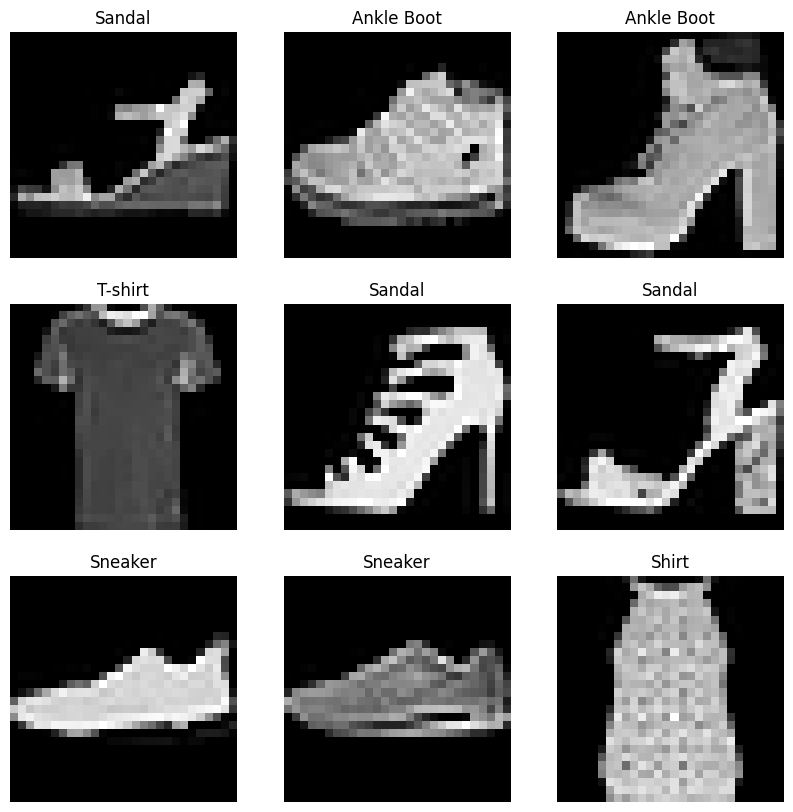

In [ ]:
# Identificando cada classe do Dataset
labels_map={
    0: 'T-shirt',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle Boot',
}

# Montando o espaço de exibição da figura
figure = plt.figure(figsize = (10,10))
cols, rows = 3, 3

# Iterando sobre o dataset para coletar 9 (conforme configuramos em cols/rows) amostras dos dados
for i in range (1, cols*rows + 1):
    sample_idx = torch.randint(len(train_data), size = (1,)).item() #.item() no final para converter tipo "tensor" para "int"
    image, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis('off')
    plt.imshow(image.squeeze(), cmap='gray')
plt.show()

# Criando o DataLoader

Shape of X [N, C, H, W]: torch.Size([128, 1, 28, 28])
Shape of y: torch.Size([128]) torch.int64


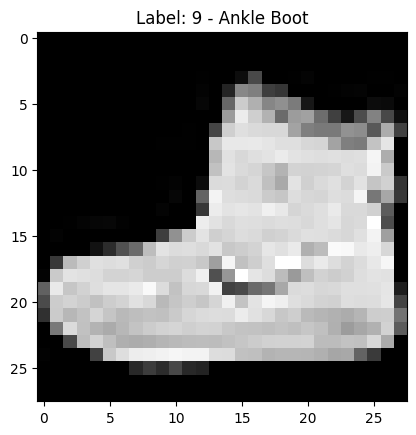

Labels batch shape: torch.Size([128])


In [ ]:
# Definindo hiperparâmetros
batch_size = 128

# Criando os data loaders (Transformando o Dataset em um iterável)
# Funções dos data loaders: gerenciar os batches, o shuffle e o carregamento paralelo
train_dl= DataLoader(train_data, batch_size=batch_size)
test_dl = DataLoader(test_data, batch_size=batch_size)

for X,y in train_dl: # X=Features y=labels
    print(f'Shape of X [N, C, H, W]: {X.shape}')
    print(f'Shape of y: {y.shape} {y.dtype}')
    image = X[0].squeeze()
    label = y[0].item()
    plt.title(f"Label: {label} - {labels_map[label]}")
    plt.imshow(image, cmap="gray")
    plt.show()
    print(f"Labels batch shape: {y.size()}")
    break

# Definindo Modelo Rede Neural

In [ ]:
import torch.nn.functional as F

In [ ]:
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.dropout = nn.Dropout(0.2) # 10% de chance de desligar um neurônio
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.leaky_relu(self.fc1(x))
        x = self.dropout(x) # Aplica dropout após a ativação da camada oculta
        x = F.leaky_relu(self.fc2(x))
        x = self.dropout(x) # Aplica dropout após a ativação da camada oculta
        x = F.leaky_relu(self.fc3(x))
        x = self.dropout(x) # Aplica dropout após a ativação da camada oculta
        x = self.fc4(x)
        return x

# Função de Custo e Otimizador

In [ ]:
import torch.optim as optim

In [ ]:
model = NeuralNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9)

# Funções de Treinamento e Avaliação



In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    return total_loss / len(dataloader), accuracy

def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return total_loss / len(dataloader), accuracy

# Loop de Treinamento

In [ ]:
epochs = 20
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_dl, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_dl, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f}, Acc: {test_acc:.2f}%")

Epoch 1/20 | Train Loss: 1.0588, Acc: 60.33% | Test Loss: 0.5529, Acc: 79.44%
Epoch 2/20 | Train Loss: 0.5412, Acc: 80.80% | Test Loss: 0.4639, Acc: 83.05%
Epoch 3/20 | Train Loss: 0.4639, Acc: 83.56% | Test Loss: 0.4208, Acc: 84.63%
Epoch 4/20 | Train Loss: 0.4232, Acc: 85.06% | Test Loss: 0.4020, Acc: 85.37%
Epoch 5/20 | Train Loss: 0.3979, Acc: 85.87% | Test Loss: 0.3872, Acc: 86.09%
Epoch 6/20 | Train Loss: 0.3766, Acc: 86.69% | Test Loss: 0.3720, Acc: 86.54%
Epoch 7/20 | Train Loss: 0.3614, Acc: 87.23% | Test Loss: 0.3577, Acc: 86.99%
Epoch 8/20 | Train Loss: 0.3489, Acc: 87.74% | Test Loss: 0.3519, Acc: 87.28%
Epoch 9/20 | Train Loss: 0.3355, Acc: 88.05% | Test Loss: 0.3470, Acc: 87.58%
Epoch 10/20 | Train Loss: 0.3249, Acc: 88.42% | Test Loss: 0.3437, Acc: 87.83%
Epoch 11/20 | Train Loss: 0.3154, Acc: 88.78% | Test Loss: 0.3388, Acc: 87.96%
Epoch 12/20 | Train Loss: 0.3075, Acc: 89.08% | Test Loss: 0.3370, Acc: 87.86%
Epoch 13/20 | Train Loss: 0.2962, Acc: 89.42% | Test Loss: 0.

In [ ]:
# 6. Salve e recarregue o modelo com torch.save e torch.load
torch.save(model.state_dict(), 'model_fashion_mnist.pth')
print('Modelo salvo com sucesso!')

# Criando uma nova instância para carregar os pesos
model_loaded = NeuralNet()
model_loaded.load_state_dict(torch.load('model_fashion_mnist.pth'))
model_loaded.eval()
print('Modelo carregado com sucesso!')

Modelo salvo com sucesso!
Modelo carregado com sucesso!


# Avaliação Final

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

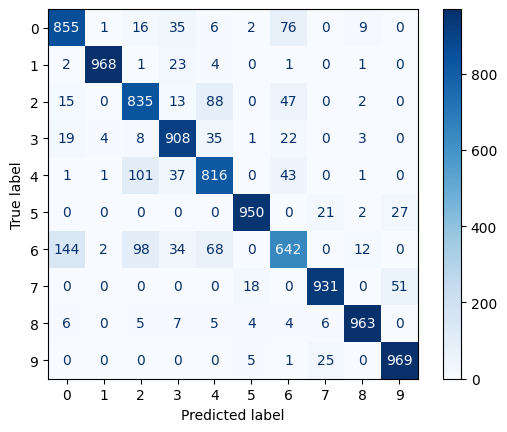

In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_dl:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues')
plt.show()

# Visualização de Acurácia e Erros

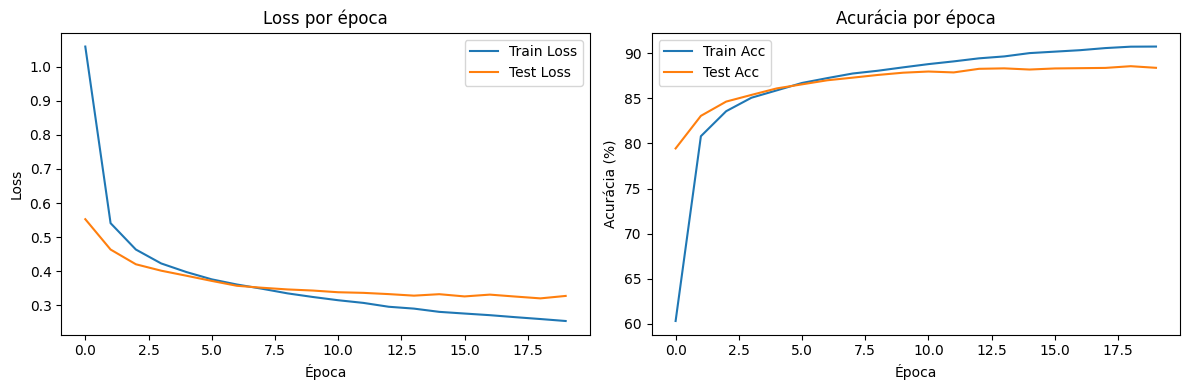

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(test_accuracies, label='Test Acc')
plt.title('Acurácia por época')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Converter as listas para arrays numpy para comparação vetorizada
all_labels_np = np.array(all_labels)
all_preds_np = np.array(all_preds)

# Comparar os arrays e contar onde eles são iguais
wrong_predictions = np.where(all_labels_np != all_preds_np)

In [ ]:
all_labels_np[wrong_predictions], all_preds_np[wrong_predictions]

(array([7, 4, 9, ..., 2, 6, 6]), array([5, 2, 5, ..., 0, 0, 0]))

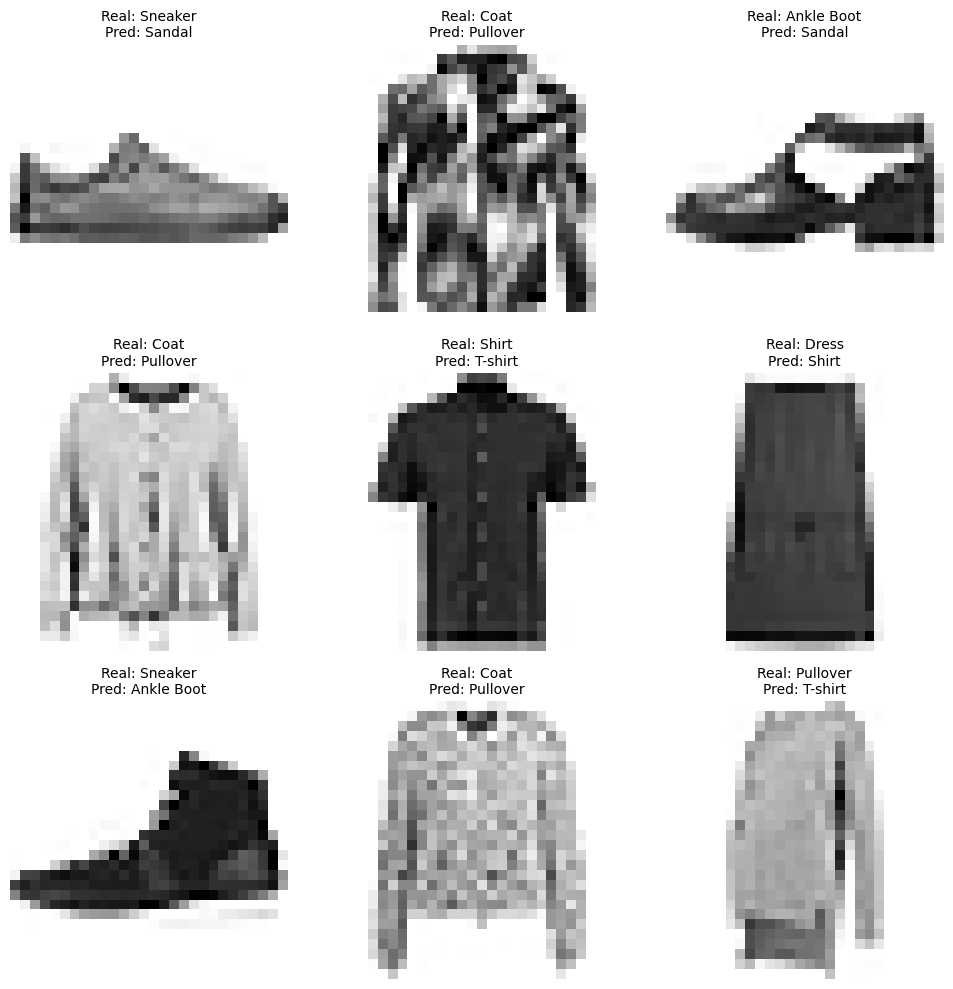

In [ ]:
# visualizar 9 imagens incorretamente classificadas em uma grade 3x3

import matplotlib.pyplot as plt

# Criar uma figura com grade 3x3 (mesmo estilo do início)
figure = plt.figure(figsize=(10, 10))
cols, rows = 3, 3

# Converter wrong_predictions para um array simples para fácil acesso
wrong_indices = wrong_predictions[0]

# Iterar para preencher a grade 3x3
for i in range(1, cols * rows + 1):
    idx = wrong_indices[i-1] # Pega o índice do erro correspondente

    # Obter a imagem e labels
    image, true_label = test_data[idx]
    predicted_label = all_preds_np[idx]

    # Configurar o subplot
    figure.add_subplot(rows, cols, i)
    plt.title(f"Real: {labels_map[true_label]}\nPred: {labels_map[predicted_label]}", fontsize=10)
    plt.axis('off')
    plt.imshow(image.squeeze(), cmap='gray_r')

plt.tight_layout()
plt.show()